# 1 Module, Globals und Daten


## 1.1 Module


In [22]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

import sklearn.metrics as skm
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

import matplotlib.pyplot as plt

import os

## 1.2 Globals

In [23]:
dataPath = 'datasets/semu/'                         # Set location of dataset

## 1.3 Daten

In [24]:
data = pd.read_csv(dataPath + 'secondary_mushroom.csv', sep=";")
xdata = data.iloc[:,:20]
ydata = data.iloc[:,20:]    # Classratio 9:11


## 1.4 Pre-Processing

### 1.4.1 Functions for 2 different encoding methods

In [25]:
def encodeLabels():
    encoders = {}

    # Create a list with the names of all columns, that contain categorical data
    xdata_cats = list(xdata.columns)
    [xdata_cats.remove(i) for i in ['cap-diameter','stem-height','stem-width']]

    # Encode all categorical feature-labels and save encoders in a dictionary
    for cat in xdata_cats:
        le = LabelEncoder()
        xdata[cat] = le.fit_transform(xdata[cat])
        encoders.update({cat:le})

    le = LabelEncoder()
    ydata['class'] = le.fit_transform(ydata['class'])
    encoders.update({'class':le})

    return encoders

def encodeOHE():
    xdata_categorical = xdata.copy()
    numeric_features = ['cap-diameter','stem-height','stem-width']

    for i in numeric_features:
        xdata_categorical = xdata_categorical.drop(i,axis=1) 

    xdata_numeric = pd.DataFrame()
    for feat in numeric_features:
        xdata_numeric[feat] = xdata[feat]

    ohe = OneHotEncoder()
    ohedata = ohe.fit_transform(xdata_categorical)

    xdata_categorical_ohe = pd.DataFrame(ohedata.toarray(), columns=ohe.get_feature_names_out(), dtype=int)

    xdata_encoded = pd.concat([xdata_numeric, xdata_categorical_ohe],axis=1)

    yEncoder = LabelEncoder()
    ydata['class'] = yEncoder.fit_transform(ydata['class'])

    return xdata_encoded, yEncoder

### 1.4.2 Encoding Function Calls

In [26]:
# encodeLabels()
xdata, yEncoder = encodeOHE() # Weil keine Rangfolge zwischen den einzelnen Kategorien herrscht, wird OHE angewendet

### 1.4.3 Data Splitting

In [27]:
xtrain_old, xvaltest, ytrain, yvaltest = train_test_split( 
    xdata,
    ydata,
    random_state=0,
    train_size=0.66,
    stratify=ydata                                  # Preserve label imbalance across train- and test datasets
)

xval_old, xtest_old, yval, ytest = train_test_split( 
    xvaltest,
    yvaltest,
    random_state=0,
    train_size=0.5,
    stratify=yvaltest                                  # Preserve label imbalance across train- and test datasets
)

ev_val_old = [(xval_old,yval)]
ev_all_old = [(xtrain_old,ytrain),(xval_old,yval),(xtest_old,ytest)]

## 1.5 Modellimport

In [28]:
# Parameters identical to clf_final in basemodell_mushroom.ipynb

clf = XGBClassifier(objective = "binary:logistic",
                    tree_method = 'exact',
                    n_estimators = 551,
                    max_depth = 7)
clf.load_model("model-exports/aktuelle-exports/base_semu.json")

# 2 Feature Selection

## 2.1 Embedded: Feature Importance

### 2.1.0 Define related funcs

In [29]:
def getFeatureImportances(model: XGBClassifier, prints: bool = False) -> list:
    
    # Erstellt eine Liste mit den relativen Wichtigkeiten aller Features des Modells nach durchschnittlichem Gain.

    featurenames  = [str(i) for i in list(model.feature_names_in_)]
    importances = [float(i) for i in list(model.feature_importances_)]

    namedimportances = list(zip(importances, featurenames))

    namedimportances = sorted(namedimportances, key=lambda x: x[0], reverse=True)

    if prints == True:
        i = 1
        for feature in namedimportances:
            print(f'{i}. {feature[1]}: \t{feature[0]}')
            i += 1

    return(namedimportances)

def getMostImportantFeatures(featureImportances, minGain: float = 0.95):
    
    # Gibt die ersten Elemente einer Liste entgegen, bis ein Wert minGain ueberschritten worden ist

    localRelWeights = []
    localFeatureNames = []
    weightsum = 0

    for feature in featureImportances:
        if (weightsum) < minGain:
            localRelWeights.append(feature[0])
            localFeatureNames.append(feature[1])
            
            weightsum += feature[0]

    return localFeatureNames, localRelWeights

def getBestDepth(listOfAccuracies, listOfSizes):  
        data = {'Accuracy': listOfAccuracies,
                'Size': listOfSizes}
        AccVsSize = pd.DataFrame(data)
        Suitable = AccVsSize[AccVsSize['Size']<1024]
        bestAccsWithinBoundaries = Suitable[Suitable['Accuracy']==max(Suitable['Accuracy'])]
        print(bestAccsWithinBoundaries)
        bestDepth = bestAccsWithinBoundaries[bestAccsWithinBoundaries['Size'] == min(bestAccsWithinBoundaries['Size'])]
        print(bestDepth)

        return bestDepth

### 2.1.1 Get (sorted) Feature Importances

In [30]:
ranking = getFeatureImportances(clf, False)
relWeights = []
featureNames = []

for feature in ranking:
    relWeights.append(feature[0])
    featureNames.append(feature[1])

rwtop = relWeights[0:10]
fntop = featureNames[0:10]

rwlist = [relWeights[0:50],relWeights[50:100],relWeights[100:128]]
fnlist = [featureNames[0:50],featureNames[50:100],featureNames[100:128]]

### 2.1.2 Plot Top 10 Features

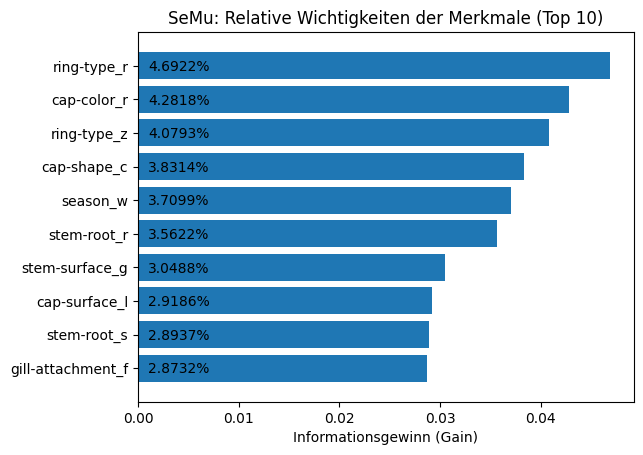

In [31]:
fig, ax = plt.subplots()

y_pos = np.arange(10)

ax.set_ylim(-1, 10)
ax.barh(y_pos, rwtop, align='center')
ax.set_yticks(y_pos, labels=fntop)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Informationsgewinn (Gain)')
ax.set_title('SeMu: Relative Wichtigkeiten der Merkmale (Top 10)')

index = 0
for i in rwtop:
    plt.text(0.001,index + 0.15,str(round(i*100,4))+"%")
    index +=1

plt.show()

### 2.1.3 Plot all Importances (50 each)

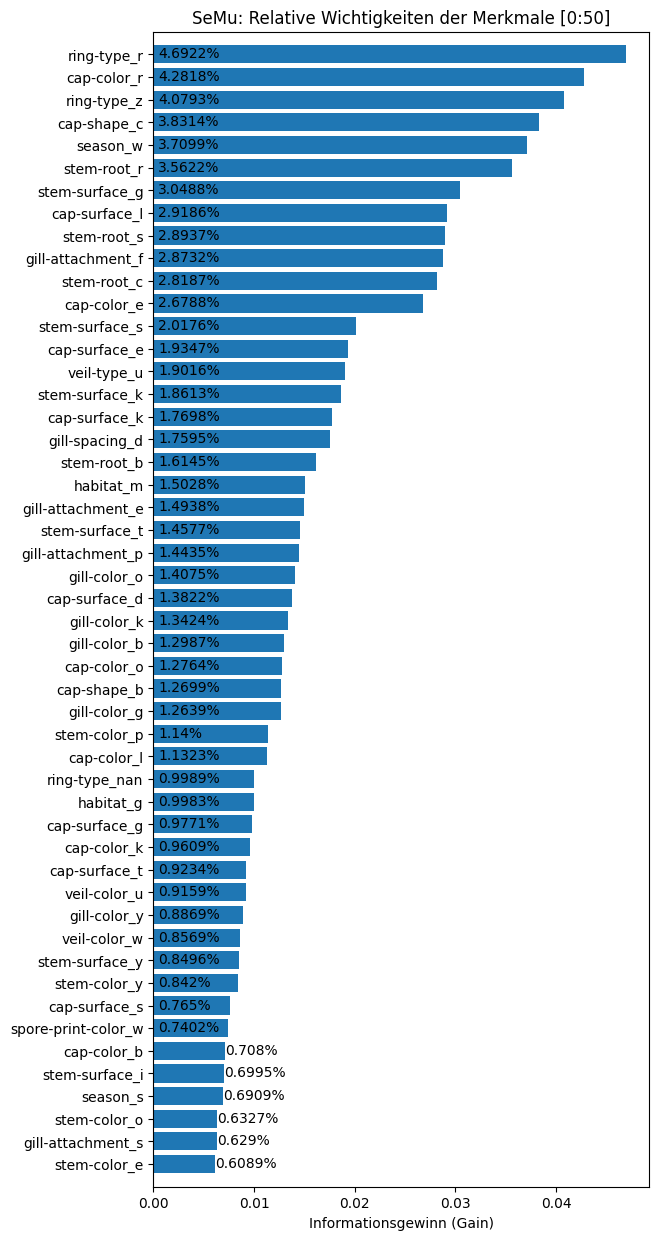

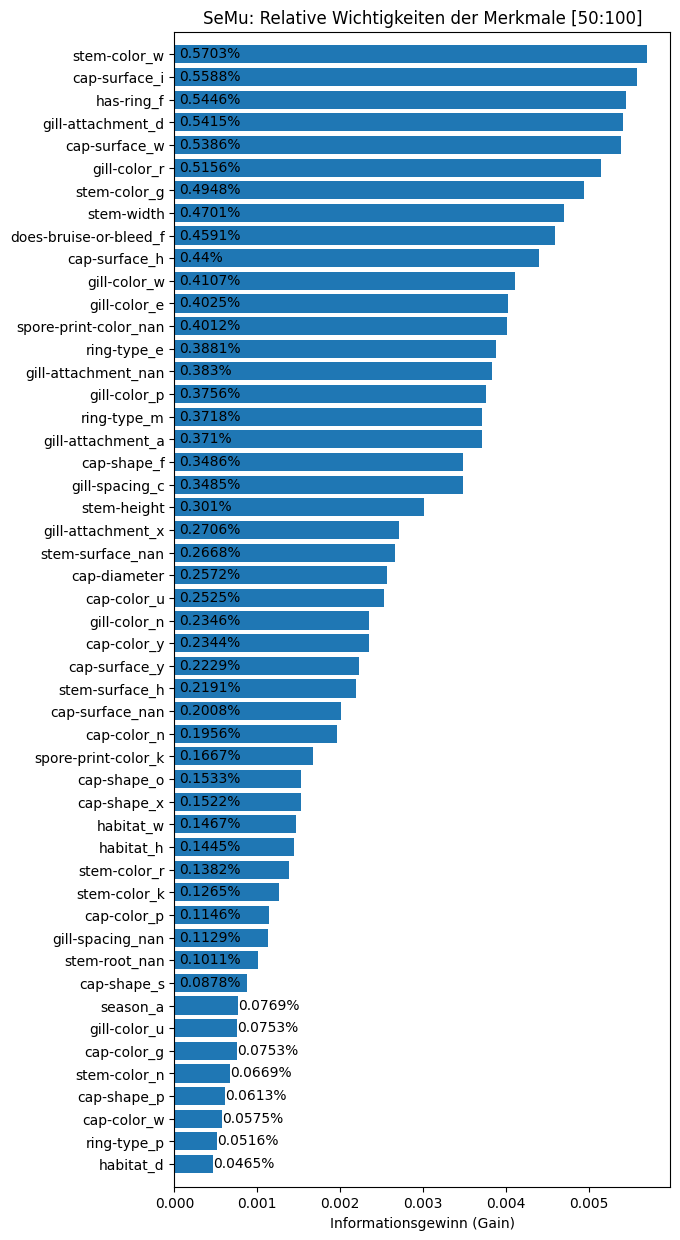

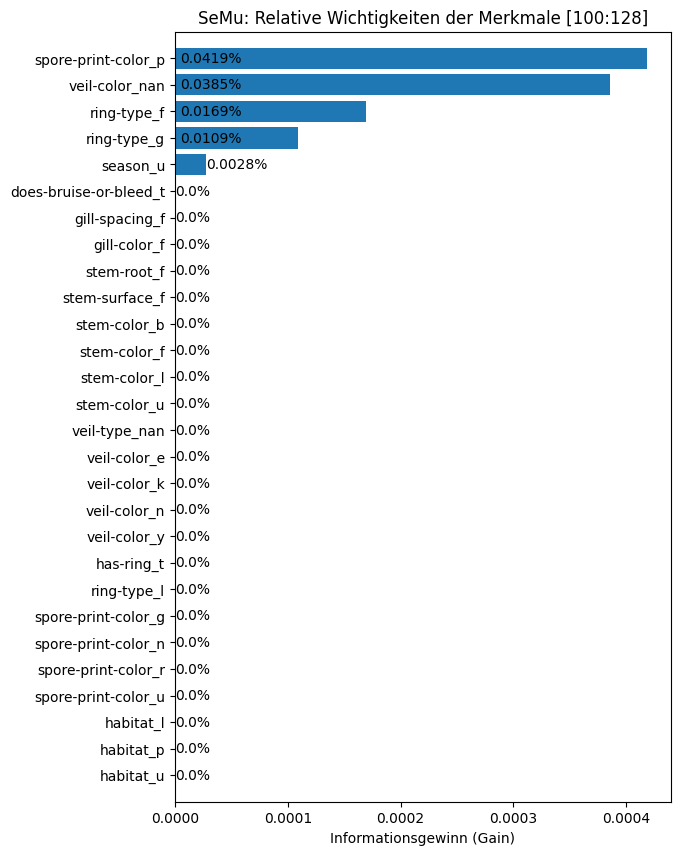

In [32]:
def plotImportances(weights, names, number):
    fig, ax = plt.subplots()

    # if len(weights) == 50: 
    fig.set_figheight(15)

    y_pos = np.arange(len(names))

    ax.set_ylim(-1, len(names))
    ax.barh(y_pos, weights, align='center')
    ax.set_yticks(y_pos, labels=names)
    ax.invert_yaxis() 
    ax.set_xlabel('Informationsgewinn (Gain)')
    ax.set_title('SeMu: Relative Wichtigkeiten der Merkmale [' + str(number*50) + ":" + str((number*50)+50) + "]")
    if number == 2:
        ax.set_title('SeMu: Relative Wichtigkeiten der Merkmale [' + str(number*50) + ":" + str(128) + "]")
        fig.set_figheight(10)
        ax.set_xticks([0.0e+00, 1.0e-04, 2.0e-04, 3.0e-04, 4.0e-04])
        

    index = 0
    for i in weights:
        if i < (weights[0]/6.5):
            plt.text(i,index + 0.15,str(round(i*100,4))+"%")
            index +=1
        else:
            plt.text((weights[0]/100),index + 0.15,str(round(i*100,4))+"%")
            index +=1

    plt.show()

for i in range(0, 3):
    plotImportances(rwlist[i], fnlist[i], i)

### 2.1.4 Get most Important Features

In [33]:
mINames, mIWeights = getMostImportantFeatures(ranking)
print(f"Gesamte Anzahl der Merkmale: {len(ranking)}")
print(f"Anzahl der Merkmale mit 95% Informationsgewinn: {len(mINames)}")

Gesamte Anzahl der Merkmale: 128
Anzahl der Merkmale mit 95% Informationsgewinn: 70


### 2.1.4 Teilmenge erstellen

In [34]:
xtrain = xtrain_old[mINames]
xval = xval_old[mINames]
xtest = xtest_old[mINames]

xtrain.to_csv("datasets/agmp/feature_selection/semu_xtrain_emb.csv", index=False, sep=",")
xval.to_csv("datasets/agmp/feature_selection/semu_xval_emb.csv",index=False, sep=",")
xtest.to_csv("datasets/agmp/feature_selection/semu_xtest_emb.csv",index=False, sep=",")

ev_val = [(xval,yval)]
ev_all = [(xtrain,ytrain),(xval,yval),(xtest,ytest)]

### 2.1.5 Modell trainieren

In [35]:
clf_fs = XGBClassifier(objective = "binary:logistic",
                       tree_method = 'exact',
                       n_estimators = 551,
                       max_depth = 7
                       )

clf_fs.fit(xtrain,ytrain,
           eval_set=ev_val,
           verbose = 0
           )

yhat = clf_fs.predict(xtest)

print(f'Accuracy-Score: \t{skm.accuracy_score(ytest, yhat)}') 

Accuracy-Score: 	0.9999036794451936


### 2.1.6 n_estimators und max_depth ermitteln

In [36]:
bestIterList = []
accList = []
jsonSizeList = []

maximum = 30

for i in range(1, maximum+1):

    clf_temp = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        n_estimators = 100000,
        early_stopping_rounds = 10,
        max_depth = i
    )
    clf_temp.fit(
        xtrain, ytrain,
        eval_set = ev_val,
        verbose = 0
    )
    
    bestIter_temp = clf_temp.best_iteration

    clf_temp_bestIter = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        n_estimators = bestIter_temp,
        max_depth = i
    )
    clf_temp_bestIter.fit(xtrain, ytrain)

    yhat_temp_bestIter = clf_temp_bestIter.predict(xtest)

    acc_temp = skm.accuracy_score(ytest, yhat_temp_bestIter)
    
    clf_temp_bestIter.save_model("clf_temp.json")

    jsonSizeList.append(os.path.getsize('clf_temp.json'))
    accList.append(acc_temp)
    bestIterList.append(bestIter_temp)

    os.remove('clf_temp.json')

### 2.1.7 Graphen für Suche nach Params plotten

In [37]:
jsonSizeList_KB = [x/1024 for x in jsonSizeList]
bestIterationValues = getBestDepth(accList, jsonSizeList_KB)
best_depth = bestIterationValues.index[0]+1

   Accuracy         Size
5       1.0  1016.795898
   Accuracy         Size
5       1.0  1016.795898


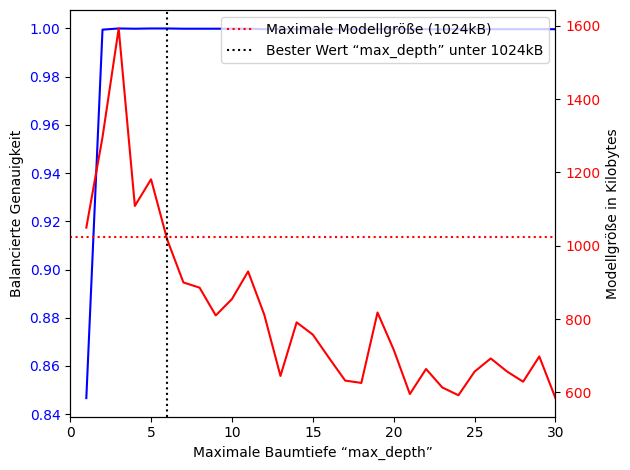

In [38]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,31),accList[:30],color="blue")
ax.set_xlim(0,30)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
# twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,31),jsonSizeList_KB[:30],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

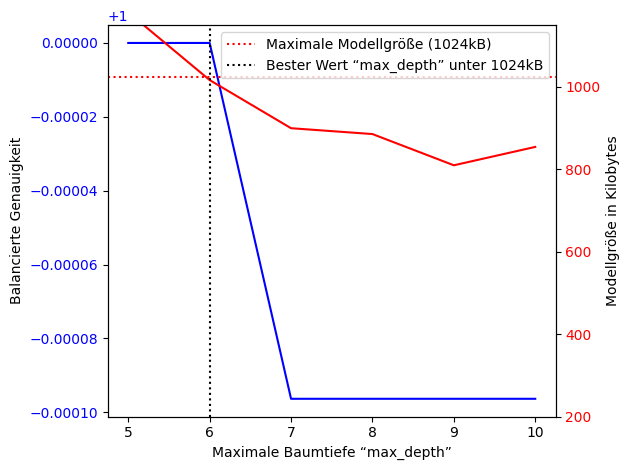

In [39]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Balancierte Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(5,11),accList[4:10],color="blue")
# ax.set_xticks([1,2,3,4,5])
# ax.set_xlim((0.8),5)

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(5,11),jsonSizeList_KB[4:10],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

### 2.1.8 Finales Modell erzeugen

In [40]:
clf_final = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    n_estimators = bestIterList[best_depth-1],
    max_depth = best_depth
)
clf_final.fit(
    xtrain,ytrain,
    eval_set = ev_all,
    verbose = 0
)

yhat_final = clf_final.predict(xtest)

clf_final.save_model("model-exports/aktuelle-exports/fs_embedded_semu.json")
clf_final.get_booster().dump_model("model-exports/aktuelle-exports/fs_embedded_semu_dump.json")

### 2.1.9 Evaluierung

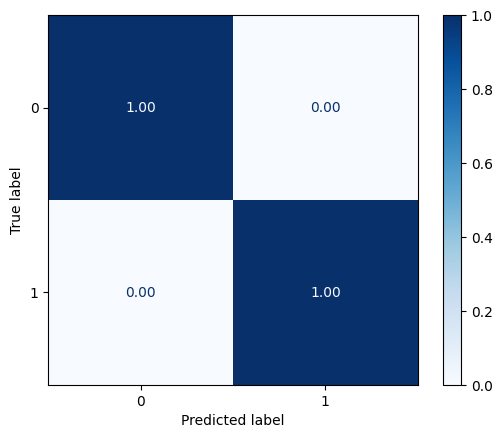

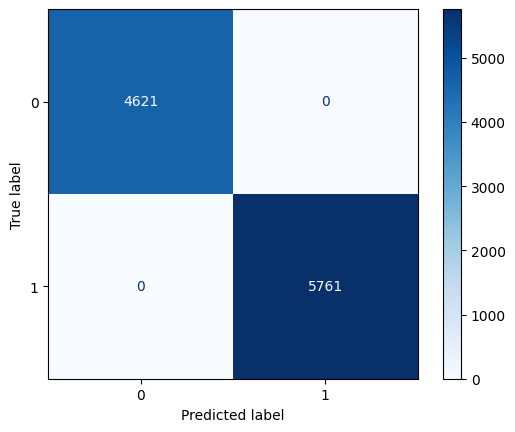

              precision    recall  f1-score   support

 0: standing   1.000000  1.000000  1.000000      4621
  1: walking   1.000000  1.000000  1.000000      5761

    accuracy                       1.000000     10382
   macro avg   1.000000  1.000000  1.000000     10382
weighted avg   1.000000  1.000000  1.000000     10382

Genauigkeit: 		 1.000000
Präzision: 		 1.000000
Sensitivität: 		 1.000000
Spezifität: 		 1.000000
NPR: 			 1.000000
F-Maß: 			 1.000000

Maximale Baumtiefe: 	 6
Anzahl Schätzer: 	 596
Anzahl der Knoten: 	 14306


In [41]:
# Konfusionsmatrizen plotten

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest, ytest, cmap='Blues', normalize='true', values_format='.2f')
plt.show()

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest, ytest, cmap="Blues" ,values_format='d')
plt.show()

print(skm.classification_report(ytest, yhat_final, labels=[0,1], target_names=['0: standing','1: walking'], digits=6))

# Kennzahlen ermitteln

tp, fp, tn, fn = 4621,0,5761,0
acc = skm.accuracy_score(ytest, yhat_final)
sens = tp/(tp + fn)
spec = tn/(tn + fn)
prec = tp/(tp + fp)
npv = tn/(tn + fn)
fscore = 2 * ((prec * sens) / (prec + sens))

print(f"Genauigkeit: \t\t {'%.6f' % acc}")
print(f"Präzision: \t\t {'%.6f' % prec}")
print(f"Sensitivität: \t\t {'%.6f' % sens}")
print(f"Spezifität: \t\t {'%.6f' % spec}")
print(f"NPR: \t\t\t {'%.6f' % npv}")
print(f"F-Maß: \t\t\t {'%.6f' % fscore}\n")

print(f"Maximale Baumtiefe: \t {best_depth}")
print(f"Anzahl Schätzer: \t {bestIterList[best_depth-1]}")
print(f"Anzahl der Knoten: \t 14306")


## 2.2 Wrapper-Methode: Rekursive Feature Eliminierung (CV)

### 2.2.1 "Optimale" Auswahl an Features ermitteln

In [42]:
min_features_to_select = 1  # Minimum number of features to consider

clf = XGBClassifier(
    objective = "binary:logistic",
    tree_method = "exact"
)
cv = StratifiedKFold(5)

rfecv = RFECV(
    estimator=clf,
    step=1,
    cv=cv,
    scoring="accuracy",
    min_features_to_select=min_features_to_select,
    n_jobs=-1,
)
rfecv.fit(xtrain_old, ytrain)

print(f"Optimal number of features: {rfecv.n_features_}")

Optimal number of features: 72


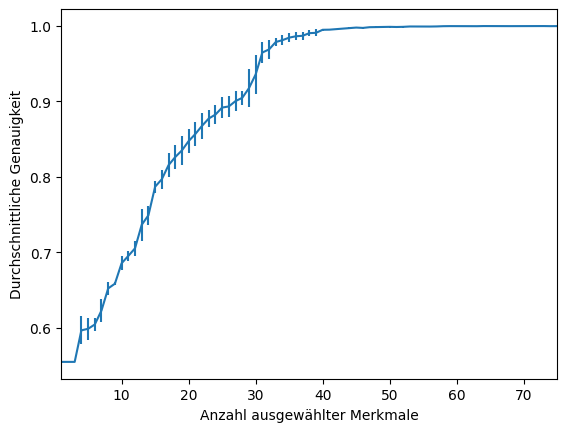

In [43]:
cv_results = pd.DataFrame(rfecv.cv_results_)
plt.figure()
plt.xlabel("Anzahl ausgewählter Merkmale")
plt.ylabel("Durchschnittliche Genauigkeit")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.xlim(1,75)
plt.show()

### 2.2.2 Teilmengen erzeugen

In [44]:
xtrain_filtered_list = [col for col, keep in zip(xtrain_old.columns, rfecv.support_) if keep]

xtrain_rfecv = xtrain_old[xtrain_filtered_list]
xval_rfecv = xval_old[xtrain_filtered_list]
xtest_rfecv = xtest_old[xtrain_filtered_list]

xtrain_rfecv.to_csv("datasets/agmp/feature_selection/semu_xtrain_rfecv.csv", index=False, sep=",")
xval_rfecv.to_csv("datasets/agmp/feature_selection/semu_xval_rfecv.csv",index=False, sep=",")
xtest_rfecv.to_csv("datasets/agmp/feature_selection/semu_xtest_rfecv.csv",index=False, sep=",")

ev_val = [(xval_rfecv,yval)]
ev_all = [(xtrain_rfecv,ytrain),(xval_rfecv,yval),(xtest_rfecv,ytest)]

### 2.2.3 Parameter für n_estimators und max_depth suchen

In [45]:
bestIterList_rfecv = []
accList_rfecv = []
jsonSizeList_rfecv = []

maximum = 30

for i in range(1, maximum+1):

    clf_temp = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        n_estimators = 100000,
        early_stopping_rounds = 10,
        max_depth = i
    )
    clf_temp.fit(
        xtrain_rfecv, ytrain,
        eval_set = ev_val,
        verbose = 0
    )
    
    bestIter_temp = clf_temp.best_iteration

    clf_temp_bestIter = XGBClassifier(
        objective = "binary:logistic",
        tree_method = "exact",
        n_estimators = bestIter_temp,
        max_depth = i
    )
    clf_temp_bestIter.fit(xtrain_rfecv, ytrain)

    yhat_temp_bestIter = clf_temp_bestIter.predict(xtest_rfecv)

    acc_temp = skm.accuracy_score(ytest, yhat_temp_bestIter)
    
    clf_temp_bestIter.save_model("clf_temp.json")

    jsonSizeList_rfecv.append(os.path.getsize('clf_temp.json'))
    accList_rfecv.append(acc_temp)
    bestIterList_rfecv.append(bestIter_temp)

    os.remove('clf_temp.json')

In [46]:
jsonSizeList_KB_rfecv = [x/1024 for x in jsonSizeList_rfecv]
bestIterationValues_rfecv = getBestDepth(accList_rfecv, jsonSizeList_KB_rfecv)
best_depth_rfecv = bestIterationValues_rfecv.index[0]+1

print(best_depth_rfecv)

   Accuracy        Size
2       1.0  947.634766
3       1.0  850.221680
4       1.0  736.199219
9       1.0  702.464844
   Accuracy        Size
9       1.0  702.464844
10


### 2.2.4 Graphen für Suche nach Params plotten

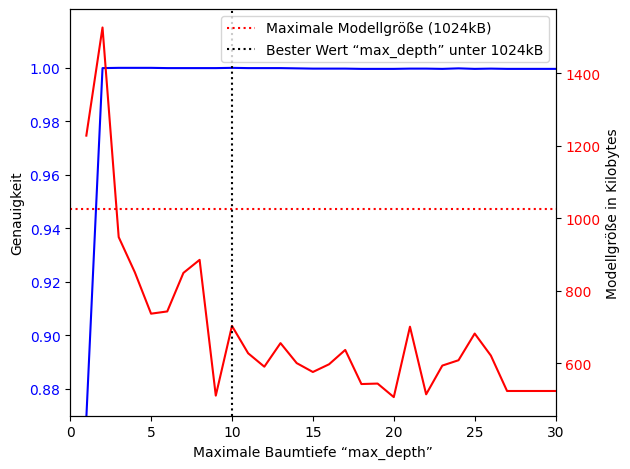

In [47]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(1,31),accList_rfecv[:30],color="blue")
ax.set_xlim(0,30)
ax.set_ylim(0.87,1.022)
ax.set_yticks([0.88,0.90,0.92,0.94,0.96,0.98,1.00])

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
# twin.set_ylim(200,1150)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(1,31),jsonSizeList_KB_rfecv[:30],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth_rfecv, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

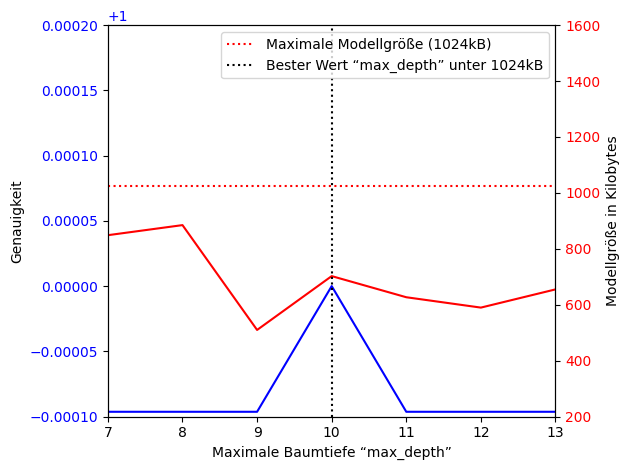

In [56]:
fig, ax = plt.subplots(1,1)

ax.set_xlabel("Maximale Baumtiefe “max_depth”")
ax.set_ylabel("Genauigkeit")
ax.tick_params(axis='y', labelcolor="blue")
ax.plot(range(7,14),accList_rfecv[6:13],color="blue")
ax.set_xticks(range(7,14))
ax.set_xlim(7,13)
ax.set_ylim(0.9999,1.0002)
# ax.set_yticks([0.88,0.90,0.92,0.94,0.96,0.98,1.00])

twin = ax.twinx()

twin.set_ylabel("Modellgröße in Kilobytes")
twin.set_ylim(200,1600)
twin.tick_params(axis='y', labelcolor="red")
twin.plot(range(7,14),jsonSizeList_KB_rfecv[6:13],color="red")

twin.axhline(y=1024, color="red", linestyle=":", label="Maximale Modellgröße (1024kB)")
twin.axvline(x=best_depth_rfecv, color="black", linestyle=":", label="Bester Wert “max_depth” unter 1024kB")

twin.legend(loc='upper right')

fig.tight_layout()
plt.show()

### 2.2.5 Finales Modell erzeugen

In [49]:
clf_final = XGBClassifier(
    objective = "binary:logistic",
    tree_method = 'exact',
    n_estimators = bestIterList_rfecv[best_depth_rfecv-1],
    max_depth = best_depth_rfecv
)
clf_final.fit(
    xtrain_rfecv,ytrain,
    eval_set = ev_all,
    verbose = 0
)

yhat_final_rfecv = clf_final.predict(xtest_rfecv)

clf_final.save_model("model-exports/aktuelle-exports/fs_rfecv_semu.json")
clf_final.get_booster().dump_model("model-exports/aktuelle-exports/fs_rfecv_semu_dump.json")

### 2.2.6 Evaluierung

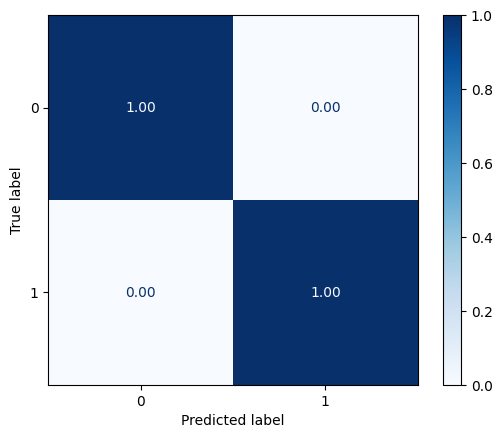

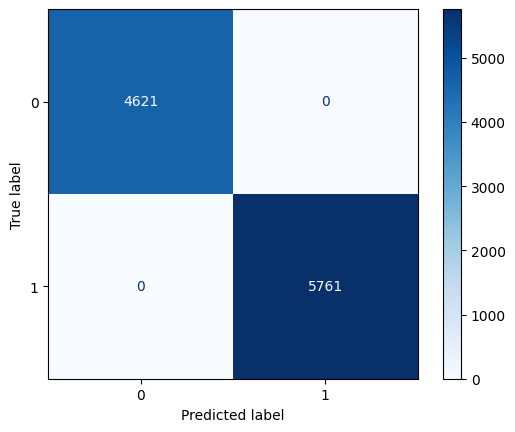

              precision    recall  f1-score   support

 0: standing   1.000000  1.000000  1.000000      4621
  1: walking   1.000000  1.000000  1.000000      5761

    accuracy                       1.000000     10382
   macro avg   1.000000  1.000000  1.000000     10382
weighted avg   1.000000  1.000000  1.000000     10382

Genauigkeit: 1.000000
Präzision: 		 0.085066
Sensitivität: 		 0.927835
Spezifität: 		 0.998402
NPR: 			 0.998402
F-Maß: 			 0.155844

Maximale Baumtiefe: 	 10
Anzahl Schätzer: 	 336
Anzahl der Knoten: 	 10338


In [50]:
# Konfusionsmatrizen plotten

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest_rfecv, ytest, cmap='Blues', normalize='true', values_format='.2f')
plt.title('')
plt.show()

skm.ConfusionMatrixDisplay.from_estimator(clf_final, xtest_rfecv, ytest, cmap="Blues" ,values_format='d')
plt.show()

print(skm.classification_report(ytest,yhat_final_rfecv, labels=[0,1], target_names=['0: standing','1: walking'], digits=6))

# Kennzahlen ermitteln

tp, fp, tn, fn = 90, 968, 4374, 7
acc = skm.accuracy_score(ytest, yhat_final_rfecv)
sens = tp/(tp + fn)
spec = tn/(tn + fn)
prec = tp/(tp + fp)
npv = tn/(tn + fn)
fscore = 2 * ((prec * sens) / (prec + sens))

print(f"Genauigkeit: {'%.6f' % acc}")
print(f"Präzision: \t\t {'%.6f' % prec}")
print(f"Sensitivität: \t\t {'%.6f' % sens}")
print(f"Spezifität: \t\t {'%.6f' % spec}")
print(f"NPR: \t\t\t {'%.6f' % npv}")
print(f"F-Maß: \t\t\t {'%.6f' % fscore}\n")

print(f"Maximale Baumtiefe: \t {best_depth_rfecv}")
print(f"Anzahl Schätzer: \t {bestIterList_rfecv[best_depth_rfecv-1]}")
print(f"Anzahl der Knoten: \t 10338")
